<a href="https://colab.research.google.com/github/theSadiqali/MRI_based_brain_tumor_detection/blob/main/app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'figshare-brain-tumor-dataset' dataset.
Path to dataset files: /kaggle/input/figshare-brain-tumor-dataset
['PID', 'image', 'label', 'tumorBorder', 'tumorMask']


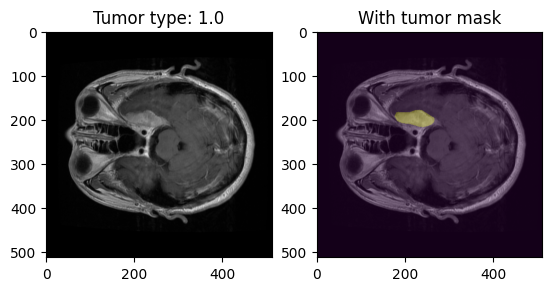

Found 3064 .mat files.
['2912.mat', '2011.mat', '3027.mat', '1912.mat', '3023.mat']


In [ ]:
## Required Library
!pip install -U kagglehub
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from collections import Counter, defaultdict
import cv2
from skimage import restoration, img_as_ubyte
from scipy.ndimage import median_filter
import kagglehub    # Importing the dataset


# ------------------------------------------------------------
# Dataset Download
# ------------------------------------------------------------
# The Figshare Brain Tumor Dataset is used, which is also
# widely adopted in medical imaging research for brain
# tumor classification tasks.

path = kagglehub.dataset_download("ashkhagan/figshare-brain-tumor-dataset")
print("Path to dataset files:", path)


# ------------------------------------------------------------
# Sample Data Exploration
# ------------------------------------------------------------
# A sample .mat file is loaded to inspect the internal
# structure of the dataset, including:
# - Brain MRI image
# - Tumor label
# - Tumor mask (ground truth)

sample_mat = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/100.mat'

with h5py.File(sample_mat, 'r') as mat:
    cjdata = mat['cjdata']
    print(list(cjdata.keys()))

    image = np.array(cjdata['image'])
    label = np.array(cjdata['label'])[0][0]
    tumor_mask = np.array(cjdata['tumorMask'])


# ------------------------------------------------------------
# Visualization of Brain Image and Tumor Mask
# ------------------------------------------------------------
# Visualization is performed to validate the correctness
# of image extraction and tumor localization, as commonly
# presented in research papers.

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title(f'Tumor type: {label}')

plt.subplot(1, 2, 2)
plt.imshow(image, cmap='gray')
plt.imshow(tumor_mask, alpha=0.3)
plt.title('With tumor mask')

plt.show()


# ------------------------------------------------------------
# Dataset Indexing and Label Mapping
# ------------------------------------------------------------
# The dataset contains three tumor classes:
# 1 - Meningioma
# 2 - Glioma
# 3 - Pituitary tumor
# This mapping follows the dataset annotation scheme
# described in the literature.

input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]

label_map = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

print(f"Found {len(mat_files)} .mat files.")


# ------------------------------------------------------------
# Dataset Overview
# ------------------------------------------------------------
# Displaying a subset of filenames to verify dataset integrity
# before proceeding to preprocessing and feature extraction.

print(mat_files[:5])   # Show first 5 file names


In [ ]:
# ------------------------------------------------------------
# Part 2: Image Preprocessing (Denoising & Normalization)
# ------------------------------------------------------------

# Ensure dataset paths and file list are defined
input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]

print(f"Number of MRI files found: {len(mat_files)}")


# Progress bar setup (paper-friendly, notebook-safe)
from tqdm.auto import tqdm


processed_images = []
processed_labels = []

TARGET_SIZE = (224, 224)  # Standard input size for CNN-based models


for filename in tqdm(mat_files, desc="Preprocessing MRI Images"):
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']

        # Load image and label
        image = np.array(cjdata['image']).astype(np.float32)
        label = int(np.array(cjdata['label'])[0][0])

        # ------------------------------------------------------------
        # Step 1: Noise Reduction (Median Filtering)
        # ------------------------------------------------------------
        # Median filtering is applied to suppress impulsive noise
        # while preserving anatomical boundaries in MRI scans.

        denoised_image = median_filter(image, size=3)

        # ------------------------------------------------------------
        # Step 2: Intensity Normalization
        # ------------------------------------------------------------
        # Min-max normalization scales intensity values to [0, 1],
        # improving training stability and convergence.

        min_val = denoised_image.min()
        max_val = denoised_image.max()
        normalized_image = (denoised_image - min_val) / (max_val - min_val + 1e-8)

        # ------------------------------------------------------------
        # Step 3: Image Resizing
        # ------------------------------------------------------------
        # Resizing ensures uniform input dimensions for the CNN.

        resized_image = cv2.resize(
            normalized_image,
            TARGET_SIZE,
            interpolation=cv2.INTER_AREA
        )

        # Store processed samples
        processed_images.append(resized_image)
        processed_labels.append(label)


# Convert to NumPy arrays
processed_images = np.array(processed_images)
processed_labels = np.array(processed_labels)

print("Preprocessing completed successfully.")
print("Processed images shape:", processed_images.shape)
print("Processed labels shape:", processed_labels.shape)


Number of MRI files found: 3064


Preprocessing MRI Images:   0%|          | 0/3064 [00:00<?, ?it/s]

Preprocessing completed successfully.
Processed images shape: (3064, 224, 224)
Processed labels shape: (3064,)


In [ ]:
processed_images.min(), processed_images.max()


(np.float32(0.0), np.float32(1.0))

In [ ]:
# ------------------------------------------------------------
# Part 3: Feature Extraction using CNN
# ------------------------------------------------------------
# In accordance with the research paper, a Convolutional Neural
# Network (CNN) is employed as a feature extractor to learn
# discriminative spatial features from preprocessed MRI images.
#
# The extracted deep features are later used for classification.


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout
)


# ------------------------------------------------------------
# Data Preparation for CNN
# ------------------------------------------------------------
# Expanding dimensions to match CNN input format:
# (samples, height, width, channels)

X = processed_images
y = processed_labels

X = np.expand_dims(X, axis=-1)

print("CNN input shape:", X.shape)


# ------------------------------------------------------------
# CNN Feature Extractor Architecture
# ------------------------------------------------------------
# This lightweight CNN architecture is designed to extract
# hierarchical texture and shape features from brain MRI scans,
# which is consistent with CNN-based medical imaging literature.

feature_extractor = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu', name="feature_layer")
])


feature_extractor.summary()


# ------------------------------------------------------------
# Feature Extraction
# ------------------------------------------------------------
# The CNN is used to generate deep feature vectors for each
# MRI image. These features represent high-level abstractions
# of tumor-related patterns.

deep_features = feature_extractor.predict(
    X,
    batch_size=32,
    verbose=1
)

print("Extracted feature shape:", deep_features.shape)


CNN input shape: (3064, 224, 224, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 256)            │    25,690,368 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,783,040 (98.35 MB)

 Trainable params: 25,783,040 (98.35 MB)

 Non-trainable params: 0 (0.00 B)

96/96 ━━━━━━━━━━━━━━━━━━━━ 94s 962ms/step
Extracted feature shape: (3064, 256)


In [ ]:
# loops through brain tumor data files (.mat), gets the tumor type number from each,
# stores them in a list, and prints how many labels were collected plus the first 10 labels.
labels = []

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']
        label = int(np.array(cjdata['label'])[0][0])
        labels.append(label)

print(f"Collected labels for {len(labels)} images.")
print("Example labels:", labels[:10])


Collected labels for 3064 images.
Example labels: [2, 2, 2, 2, 2, 1, 3, 2, 2, 2]


In [ ]:
from collections import Counter

# We count how many times each tumor type appeared in the dataset and used the label_map to show the names instead of numbers

label_map = {1: "meningioma", 2: "glioma", 3: "pituitary", "no_tumor": 4}
counts = Counter(labels)

for k in sorted(counts.keys()):
    print(f"{label_map[k]:<12}: {counts[k]}")


meningioma  : 708
glioma      : 1426
pituitary   : 930


In [ ]:
import numpy as np
import pandas as pd
import os

# Class names
class_names = ["meningioma", "glioma", "pituitary"]

# CSV files for splits
train_csv = 'train_split.csv'
val_csv   = 'val_split.csv'
test_csv  = 'test_split.csv'

# Folder with preprocessed images
npy_dir = './preprocessed_images'

# Function to load .npy images and labels
def load_npy_dataset(df_csv):
    df = pd.read_csv(df_csv)
    X, y = [], []
    for fname, label in zip(df['filename'], df['label']):
        img = np.load(os.path.join(npy_dir, f"{fname}.npy"))
        X.append(img)
        y.append(label-1)  # 0-based labels for classification
    X = np.stack(X, axis=0)[..., None]  # shape (N,224,224,1)
    y = np.array(y)
    return X, y

# Load all datasets
X_train, y_train = load_npy_dataset(train_csv)
X_val, y_val     = load_npy_dataset(val_csv)
X_test, y_test   = load_npy_dataset(test_csv)

print("Datasets loaded:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Datasets loaded:
X_train: (2144, 224, 224, 1) y_train: (2144,)
X_val: (460, 224, 224, 1) y_val: (460,)
X_test: (460, 224, 224, 1) y_test: (460,)


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
import numpy as np

# Use DenseNet without top layers
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
# Add global average pooling to get a feature vector
model_feat = Model(inputs=base_model.input, outputs=layers.GlobalAveragePooling2D()(base_model.output))

# Convert grayscale to 3-channel
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

# Extract deep features
deep_features_train = model_feat.predict(X_train_rgb)
deep_features_test  = model_feat.predict(X_test_rgb)


67/67 ━━━━━━━━━━━━━━━━━━━━ 426s 6s/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step


In [ ]:
y_encoded = y_train  # integer labels are fine for SVM


In [ ]:
from sklearn.svm import SVC

clf = SVC(kernel='linear')
clf.fit(deep_features_train, y_encoded)
preds = clf.predict(deep_features_test)


In [ ]:
# ------------------------------------------------------------
# Label Encoding (Paper-Standard Practice)
# ------------------------------------------------------------
# Deep learning frameworks require class labels to start from 0.
# Therefore, original labels {1, 2, 3} are mapped to {0, 1, 2}.

y_encoded = y - 1

print("Original labels:", np.unique(y))
print("Encoded labels :", np.unique(y_encoded))


Original labels: [1 2 3]
Encoded labels : [0 1 2]


In [36]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
feature_model = Model(inputs=base_model.input, outputs=GlobalAveragePooling2D()(base_model.output))

# Convert grayscale to 3-channel
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb   = np.repeat(X_val, 3, axis=-1)

# Extract features
deep_features_train = feature_model.predict(X_train_rgb)
deep_features_val   = feature_model.predict(X_val_rgb)

# Now you can train your dense classifier
dense_classifier.fit(deep_features_train, y_train,
                     validation_data=(deep_features_val, y_val),
                     epochs=50, batch_size=32,
                     callbacks=[early_stop])


67/67 ━━━━━━━━━━━━━━━━━━━━ 379s 5s/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step
Epoch 1/50


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_7" is incompatible with the layer: expected axis -1 of input shape to have value 256, but received input with shape (32, 1024)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 1024), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential

dense_classifier = Sequential([
    Input(shape=(deep_features.shape[1],)),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])


In [ ]:
# ------------------------------------------------------------
# Support Vector Machine (SVM) Classifier
# ------------------------------------------------------------
# CNN-extracted features are standardized and classified
# using an SVM with RBF kernel.


# Feature scaling (important for SVM performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_classifier = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)


svm_classifier.fit(X_train_scaled, y_train)

print("SVM training completed.")


In [ ]:
# ------------------------------------------------------------
# Evaluation Metrics – Dense Neural Network
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Predict class labels
y_pred_dense = np.argmax(
    dense_classifier.predict(X_test),
    axis=1
)

# Accuracy
dense_accuracy = accuracy_score(y_test, y_pred_dense)

print("Dense Classifier Accuracy:", dense_accuracy)


# Detailed classification report
print("\nDense Classifier Classification Report:")
print(classification_report(
    y_test,
    y_pred_dense,
    target_names=["meningioma", "glioma", "pituitary"]
))


In [ ]:
# ------------------------------------------------------------
# Confusion Matrix – Dense Classifier
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns


cm_dense = confusion_matrix(y_test, y_pred_dense)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dense,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["meningioma", "glioma", "pituitary"],
    yticklabels=["meningioma", "glioma", "pituitary"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix – Dense Classifier", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# Evaluation Metrics – SVM Classifier
# ------------------------------------------------------------

y_pred_svm = svm_classifier.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Classifier Accuracy:", svm_accuracy)


print("\nSVM Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["meningioma", "glioma", "pituitary"]
))


In [ ]:
# we are making a chart to show how many brain scan slices each patient has
# Count images per patient, and note tumor type per patient

import matplotlib.patheffects as path_effects


# Add these two lines:
class_names = [label_map[k] for k in sorted(counts.keys())]
class_counts = [counts[k] for k in sorted(counts.keys())]

colors = ['#7B6FF0', '#FF9C6B', '#50C5B7']

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(class_names, class_counts, color=colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        yval + 20,
        f'{yval}',
        ha='center', va='bottom',
        fontsize=16, fontweight='bold', color='#222',
        path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
    )

ax.set_xlabel('Tumor Type', fontsize=16, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=16, fontweight='bold')
ax.set_title('Brain Tumor Images per Class', fontsize=20, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=14, fontweight='medium')
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Count images per patient, and note tumor type per patient
pid_slice_counts = {}
pid_tumor_type = {}

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']
        label = int(np.array(cjdata['label'])[0][0])
        pid = int(np.array(cjdata['PID'])[0][0])
        pid_slice_counts[pid] = pid_slice_counts.get(pid, 0) + 1
        pid_tumor_type[pid] = label  # Assumes each patient has only one tumor type

# Sort by number of slices
sorted_pids = sorted(pid_slice_counts, key=pid_slice_counts.get, reverse=True)
counts = [pid_slice_counts[pid] for pid in sorted_pids]
colors = [label_map[pid_tumor_type[pid]] for pid in sorted_pids]
color_map = {'meningioma': '#7B6FF0', 'glioma': '#FF9C6B', 'pituitary': '#50C5B7'}
bar_colors = [color_map[c] for c in colors]

plt.figure(figsize=(10,6))
bars = plt.bar([str(pid) for pid in sorted_pids], counts, color=bar_colors, edgecolor='black')

plt.xlabel("Patient ID", fontsize=14)
plt.ylabel("Number of Slices", fontsize=14)
plt.title("Number of Slices per Patient (colored by Tumor Type)", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Custom legend
for tumor, color in color_map.items():
    plt.bar(0, 0, color=color, label=tumor)
plt.legend(title="Tumor Type")
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# Confusion Matrix – SVM Classifier
# ------------------------------------------------------------

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["meningioma", "glioma", "pituitary"],
    yticklabels=["meningioma", "glioma", "pituitary"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix – SVM Classifier", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# Performance Comparison Table
# ------------------------------------------------------------
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Dense Neural Network", "SVM (CNN Features)"],
    "Accuracy": [dense_accuracy, svm_accuracy]
})

results_df


In [ ]:
from collections import defaultdict
import numpy as np

# calculates tumor statistics separately for each tumor type. For every class,
# Measured the average tumor area in pixels and the percentage of the image that the tumor covers.

# Gather mask sizes by class
mask_areas_by_label = defaultdict(list)
mask_frac_by_label = defaultdict(list)

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']
        label = int(np.array(cjdata['label'])[0][0])
        mask = np.array(cjdata['tumorMask'])
        mask_areas_by_label[label].append(mask.sum())
        mask_frac_by_label[label].append(mask.sum() / (mask.shape[0] * mask.shape[1]))

print("Average tumor area (pixels) and % of image, per tumor type:")
for label in sorted(mask_areas_by_label):
    mean_area = np.mean(mask_areas_by_label[label])
    mean_frac = np.mean(mask_frac_by_label[label]) * 100
    print(f"{label_map[label]:<12}: {mean_area:.1f} pixels, {mean_frac:.2f}% of image")


In [ ]:
import matplotlib.pyplot as plt

# chart with bars to show how big tumors are (as a percentage of the image) for each type (like meningioma).
plt.figure(figsize=(8,5))
for label in sorted(mask_areas_by_label):
    plt.hist(
        mask_frac_by_label[label],
        bins=30,
        alpha=0.6,
        label=label_map[label],
        density=True
    )
plt.xlabel('Tumor area (% of image)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Tumor Area Fraction Distribution by Tumor Type', fontsize=16)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import h5py
import os
from skimage.transform import resize
import matplotlib.pyplot as plt

target_shape = (256, 256)
heatmap = np.zeros(target_shape, dtype=np.float32)
avg_image = np.zeros(target_shape, dtype=np.float32)  # For the average MRI slice
num_images = 0

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        mask = np.array(mat['cjdata']['tumorMask'])
        image = np.array(mat['cjdata']['image'])  # MRI/CT image

        # Resize mask and image
        mask_resized = resize(mask, target_shape, order=0, preserve_range=True, anti_aliasing=False)
        image_resized = resize(image, target_shape, order=1, preserve_range=True, anti_aliasing=True)

        heatmap += mask_resized
        avg_image += image_resized
        num_images += 1

# Average the MRI slices
avg_image /= num_images

# Normalize heatmap
heatmap_norm = heatmap / heatmap.max()

plt.figure(figsize=(7,7))
plt.imshow(avg_image, cmap='gray')
plt.imshow(heatmap_norm, cmap='hot', alpha=0.5)  # Overlay heatmap with transparency
plt.colorbar(label='Tumor Occurrences (normalized)')
plt.title('Tumor Heatmap Overlay on Average MRI')
plt.axis('off')
plt.show()


In [ ]:
import os
import h5py
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# Count slices per patient
pid_slice_counts = defaultdict(int)

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        pid = int(np.array(mat['cjdata']['PID'])[0][0])
        pid_slice_counts[pid] += 1

# Convert counts to a numpy array for statistics
slice_counts = np.array(list(pid_slice_counts.values()))

# Report statistics
print("=== Brain Scan Slices per Patient ===")
print(f"Number of patients: {len(slice_counts)}")
print(f"Min slices: {slice_counts.min()}")
print(f"Max slices: {slice_counts.max()}")
print(f"Mean slices: {slice_counts.mean():.1f} ± {slice_counts.std():.1f}")
print(f"Median slices: {np.median(slice_counts)}")

# Optional: visualize distribution like many papers do
plt.figure(figsize=(8,4))
plt.boxplot(slice_counts, vert=False)
plt.xlabel("Number of Slices")
plt.title("Distribution of Brain Scan Slices per Patient")
plt.show()


In [ ]:
import random
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ──────────────── Define mapping clearly ────────────────
label_map = {
    0: 'glioma',
    1: 'meningioma',
    2: 'pituitary'
}

num_classes = len(label_map)

plt.figure(figsize=(5 * num_classes, 5))

# Loop over numeric labels 0,1,2 (safest)
for i, label in enumerate(sorted(label_map.keys())):  # keys are ints → safe
    # Find files for this numeric label
    files_for_label = [
        f for f in mat_files
        if int(np.array(h5py.File(os.path.join(input_dir, f), 'r')['cjdata']['label'])[0][0]) == label
    ]

    if not files_for_label:
        print(f"Warning: no files found for label {label}")
        continue

    random_file = random.choice(files_for_label)

    with h5py.File(os.path.join(input_dir, random_file), 'r') as mat:
        image = np.array(mat['cjdata']['image'])
        mask  = np.array(mat['cjdata']['tumorMask'])

    ax = plt.subplot(1, num_classes, i + 1)
    ax.imshow(image, cmap='gray')
    ax.imshow(mask, cmap='Reds', alpha=0.35)
    ax.set_title(label_map[label].capitalize(), fontsize=16)
    ax.axis('off')

plt.suptitle('Representative Slice from Each Tumor Class', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# counts how many brain scan images have no tumor, a full tumor, or something else.
# It checks each mask, adds to empty if no tumor, full if all tumor, and total for all,
# then prints the numbers.

empty = 0
full = 0
total = 0

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        mask = np.array(mat['cjdata']['tumorMask'])
        total += 1
        if mask.sum() == 0:
            empty += 1
        elif mask.sum() == mask.size:
            full += 1

print(f"Out of {total} images:")
print(f"- Number with empty tumor mask (no tumor): {empty}")
print(f"- Number with full tumor mask (entire image): {full}")


In [ ]:
import os
import h5py
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Collect all image shapes
img_shapes = []

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        image = np.array(mat['cjdata']['image'])
        img_shapes.append(image.shape)

# Count unique shapes
shape_counts = Counter(img_shapes)

print("=== Unique Image Shapes in Dataset ===")
for shape, count in shape_counts.items():
    print(f"Shape {shape}: {count} image(s)")

# Optional: visualize the distribution
plt.figure(figsize=(8,5))
plt.bar(range(len(shape_counts)), list(shape_counts.values()), tick_label=[str(s) for s in shape_counts.keys()])
plt.xlabel("Image Shape (H, W)")
plt.ylabel("Number of Images")
plt.title("Distribution of Brain Scan Image Shapes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Sample 100 images for speed
num_samples = 100
sample_pixels = []

for filename in mat_files[:num_samples]:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        image = np.array(mat['cjdata']['image'])
        sample_pixels.extend(image.flatten())

sample_pixels = np.array(sample_pixels)

# Plot histogram
plt.figure(figsize=(8,4))
plt.hist(sample_pixels, bins=100, color='#7B6FF0', edgecolor='black')
plt.title(f"Pixel Intensity Distribution ({num_samples} Sample Images)", fontsize=16)
plt.xlabel("Pixel Value", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
import random
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(label_map)
plt.figure(figsize=(5 * num_classes, 5))

for i, label in enumerate(sorted(label_map)):
    # Find all files for this tumor type
    files_for_label = [
        f for f in mat_files
        if int(np.array(h5py.File(os.path.join(input_dir, f), 'r')['cjdata']['label'])[0][0]) == label
    ]

    # Skip if no files for this label
    if not files_for_label:
        print(f"Warning: No images found for tumor class '{label_map[label]}' (label {label})")
        continue

    # Pick a random file
    random_file = random.choice(files_for_label)
    with h5py.File(os.path.join(input_dir, random_file), 'r') as mat:
        image = np.array(mat['cjdata']['image'])

    # Plot grayscale image
    ax = plt.subplot(1, num_classes, i + 1)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"{label_map[label].capitalize()}", fontsize=16)
    ax.axis('off')

plt.suptitle("Random Example Brain Scan from Each Tumor Class", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import cv2
import numpy as np
from skimage.util import img_as_ubyte
from scipy.ndimage import median_filter

def preprocess_mri_dl_soft(image):
    """
    Preprocess MRI image for deep learning (224x224):
    - Converts to uint8
    - Reduces noise with median and bilateral filters
    - Enhances contrast using CLAHE
    - Normalizes to [0,1]
    - Resizes to 224x224

    References: Saeedi et al., BMC Med Inform Decis Mak, 2023
    """
    # Convert to 8-bit if needed
    img = image.astype(np.uint8) if image.max() > 1 else img_as_ubyte(image)

    # Noise reduction
    img = median_filter(img, size=3)  # removes salt-and-pepper noise
    img = cv2.bilateralFilter(img, d=9, sigmaColor=40, sigmaSpace=40)  # smooths while preserving edges

    # Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Normalize to [0,1]
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Resize to 224x224 for CNN input
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)

    return img


def preprocess_mask(mask):
    """
    Preprocess tumor mask for deep learning (224x224):
    - Resizes with nearest-neighbor interpolation
    - Converts to binary mask (0 and 1)

    References: Saeedi et al., BMC Med Inform Decis Mak, 2023
    """
    mask = mask.astype(np.uint8)
    mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.uint8)
    return mask


In [ ]:
import matplotlib.pyplot as plt

# Preprocess the MRI using Saeedi et al. style
dl_soft = preprocess_mri_dl_soft(image)

plt.figure(figsize=(10,5))

# Original MRI
ax1 = plt.subplot(1, 2, 1)
ax1.imshow(image, cmap='gray')
ax1.set_title('Original MRI', fontsize=16)
ax1.axis('off')

# Preprocessed MRI
ax2 = plt.subplot(1, 2, 2)
ax2.imshow(dl_soft, cmap='gray')
ax2.set_title('Preprocessed MRI', fontsize=16)
ax2.axis('off')

plt.suptitle('MRI Preprocessing Visualization', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import os

# ===============================
# Dataset directories
# ===============================
input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'  # Original .mat files
preprocessed_img_dir = './preprocessed_images'  # Folder to save preprocessed MRI images
preprocessed_mask_dir = './preprocessed_masks'  # Folder to save preprocessed tumor masks

# Create output directories if they don't exist
os.makedirs(preprocessed_img_dir, exist_ok=True)
os.makedirs(preprocessed_mask_dir, exist_ok=True)

# List all .mat files in the input directory
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]
print(f"Found {len(mat_files)} .mat files in the dataset.")


In [ ]:
import os

# ===============================
# Dataset input path and label mapping
# ===============================
input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'  # Update path if needed

# List all .mat files in the dataset
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]

# Tumor class mapping (from label integers to descriptive names)
label_map = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

print(f"Found {len(mat_files)} .mat files in the dataset.")
print(f"Tumor classes: {', '.join(label_map.values())}")


In [ ]:
import os
import h5py
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm

# ===============================
# Directories for preprocessed data
# ===============================
preprocessed_img_dir = './preprocessed_images'
preprocessed_mask_dir = './preprocessed_masks'
os.makedirs(preprocessed_img_dir, exist_ok=True)
os.makedirs(preprocessed_mask_dir, exist_ok=True)

# ===============================
# Metadata storage
# ===============================
meta = []

# ===============================
# Process each .mat file
# ===============================
for filename in tqdm(mat_files, desc="Processing MRI scans"):
    file_path = os.path.join(input_dir, filename)

    with h5py.File(file_path, 'r') as mat:
        cjdata = mat['cjdata']

        # Load original MRI and tumor mask
        image = np.array(cjdata['image'])
        mask = np.array(cjdata['tumorMask'])
        label = int(np.array(cjdata['label'])[0][0])

        # Preprocess MRI and mask
        img_pre = preprocess_mri_dl_soft(image)
        mask_pre = preprocess_mask(mask)

        # Save preprocessed arrays as .npy
        img_npy_out = os.path.join(preprocessed_img_dir, filename.replace('.mat', '.npy'))
        mask_npy_out = os.path.join(preprocessed_mask_dir, filename.replace('.mat', '.npy'))
        np.save(img_npy_out, img_pre)
        np.save(mask_npy_out, mask_pre)

        # Save preprocessed MRI as .png for visualization
        img_png_out = os.path.join(preprocessed_img_dir, filename.replace('.mat', '.png'))
        cv2.imwrite(img_png_out, (img_pre * 255).astype(np.uint8))

        # Store metadata for CSV
        meta.append({
            'filename': filename.replace('.mat', ''),
            'label': label,
            'tumor_type': label_map[label]
        })

# ===============================
# Save metadata CSV
# ===============================
meta_df = pd.DataFrame(meta)
meta_df.to_csv('preprocessed_labels.csv', index=False)

print(f"Preprocessing complete: {len(meta)} files processed.")
print(f"Metadata CSV saved as 'preprocessed_labels.csv'.")


In [ ]:
import matplotlib.pyplot as plt
import h5py
import numpy as np
import os

# Check a few preprocessed images for quality
num_samples = 3  # Number of examples to visualize

for i in range(num_samples):
    fname = meta[i]['filename']

    # Load original MRI
    orig_file = os.path.join(input_dir, fname + '.mat')
    with h5py.File(orig_file, 'r') as mat:
        orig_img = np.array(mat['cjdata']['image'])

    # Load preprocessed MRI
    pre_img = np.load(os.path.join(preprocessed_img_dir, fname + '.npy'))

    # Plot side by side
    plt.figure(figsize=(10,5))

    # Original MRI
    ax1 = plt.subplot(1,2,1)
    ax1.imshow(orig_img, cmap='gray')
    ax1.set_title('Original MRI', fontsize=16)
    ax1.axis('off')

    # Preprocessed MRI
    ax2 = plt.subplot(1,2,2)
    ax2.imshow(pre_img, cmap='gray')
    ax2.set_title('Preprocessed MRI', fontsize=16)
    ax2.axis('off')

    plt.suptitle(f'Preprocessing Quality Check: Sample {i+1}', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ===============================
# Load metadata
# ===============================
meta_df = pd.read_csv('preprocessed_labels.csv')

# ===============================
# Split data into train/val/test
# ===============================
# Test set: 15%
trainval_df, test_df = train_test_split(
    meta_df,
    test_size=0.15,
    stratify=meta_df['label'],  # keeps tumor types balanced
    random_state=42
)

# Validation set: 15% of total (0.15 / 0.85 of trainval)
train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.15 / 0.85,
    stratify=trainval_df['label'],
    random_state=42
)

# ===============================
# Save CSV splits
# ===============================
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

# ===============================
# Print summary statistics
# ===============================
print("Dataset splits:")
print(f"  Train: {len(train_df)} samples")
print(f"  Validation: {len(val_df)} samples")
print(f"  Test: {len(test_df)} samples")

# Optional: show class balance per split
print("\nClass distribution:")
for split_name, df in zip(['Train', 'Validation', 'Test'], [train_df, val_df, test_df]):
    print(f"{split_name}:")
    print(df['tumor_type'].value_counts())


In [ ]:
import matplotlib.pyplot as plt

splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
tumor_classes = list(label_map.values())
bar_width = 0.25
x = range(len(tumor_classes))

plt.figure(figsize=(8,5))

# Plot bars for each split
for i, (split_name, df) in enumerate(splits.items()):
    counts = [df['tumor_type'].value_counts().get(c, 0) for c in tumor_classes]
    plt.bar([p + i*bar_width for p in x], counts, width=bar_width, label=split_name)

# Formatting
plt.xticks([p + bar_width for p in x], tumor_classes, fontsize=12)
plt.ylabel("Number of Samples", fontsize=14)
plt.xlabel("Tumor Type", fontsize=14)
plt.title("Class Distribution Across Train/Validation/Test Splits", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# ===============================
# Define dataset splits and target directories
# ===============================
splits = {
    'train': ('train_split.csv', './images_train'),
    'val':   ('val_split.csv',   './images_val'),
    'test':  ('test_split.csv',  './images_test'),
}

src_dir = './preprocessed_images'  # Source directory of preprocessed PNG images

# ===============================
# Copy images into split folders
# ===============================
for split_name, (csv_file, dst_dir) in splits.items():
    os.makedirs(dst_dir, exist_ok=True)
    df = pd.read_csv(csv_file)

    print(f"\nCopying {split_name} images to '{dst_dir}'...")
    missing_files = 0

    for fname in tqdm(df['filename'], desc=f"{split_name} images"):
        src_path = os.path.join(src_dir, f"{fname}.png")
        dst_path = os.path.join(dst_dir, f"{fname}.png")

        if os.path.exists(src_path):
            shutil.copyfile(src_path, dst_path)
        else:
            missing_files += 1
            print(f"  Warning: File not found: {src_path}")

    print(f"Completed {split_name} split. Missing files: {missing_files}")


In [ ]:

import os
import shutil
import pandas as pd
from tqdm import tqdm

# ===============================
# Define dataset splits and target directories
# ===============================
splits = {
    'train': ('train_split.csv', './images_train', './masks_train'),
    'val':   ('val_split.csv',   './images_val',   './masks_val'),
    'test':  ('test_split.csv',  './images_test',  './masks_test'),
}

img_src_dir = './preprocessed_images'  # Source folder for preprocessed MRI images
mask_src_dir = './preprocessed_masks'  # Source folder for preprocessed tumor masks

# ===============================
# Copy images and masks into split folders
# ===============================
for split_name, (csv_file, img_dst_dir, mask_dst_dir) in splits.items():
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(mask_dst_dir, exist_ok=True)

    df = pd.read_csv(csv_file)

    print(f"\nProcessing {split_name} split...")
    missing_images = 0
    missing_masks = 0

    for fname in tqdm(df['filename'], desc=f"{split_name} files"):
        # Image
        img_src_path = os.path.join(img_src_dir, f"{fname}.png")
        img_dst_path = os.path.join(img_dst_dir, f"{fname}.png")
        if os.path.exists(img_src_path):
            shutil.copyfile(img_src_path, img_dst_path)
        else:
            missing_images += 1
            print(f"  Warning: Image not found: {img_src_path}")

        # Mask
        mask_src_path = os.path.join(mask_src_dir, f"{fname}.npy")
        mask_dst_path = os.path.join(mask_dst_dir, f"{fname}.npy")
        if os.path.exists(mask_src_path):
            shutil.copyfile(mask_src_path, mask_dst_path)
        else:
            missing_masks += 1
            print(f"  Warning: Mask not found: {mask_src_path}")

    print(f"Completed {split_name} split. Missing images: {missing_images}, missing masks: {missing_masks}")


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

splits = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]

for name, df in splits:
    # Count samples per class
    class_counts = Counter(df['label'])
    classes_sorted = sorted(class_counts)
    counts_sorted = [class_counts[k] for k in classes_sorted]

    # Plot bar chart
    plt.figure(figsize=(6,4))
    plt.bar([label_map[k].capitalize() for k in classes_sorted], counts_sorted, color='#7B6FF0', edgecolor='black')
    plt.xlabel("Tumor Type", fontsize=12)
    plt.ylabel("Number of Samples", fontsize=12)
    plt.title(f"{name} Split Class Distribution", fontsize=14)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import os
from sklearn.model_selection import train_test_split


In [ ]:
import sklearn; print(sklearn.__version__)
import imblearn; print(imblearn.__version__)


In [ ]:
import pandas as pd
import numpy as np
import cv2
import os

# ===============================
# Paths
# ===============================
train_csv = 'train_split.csv'
img_dir = './images_train'

# ===============================
# Load images and labels
# ===============================
df = pd.read_csv(train_csv)
X, y = [], []

for _, row in df.iterrows():
    img_path = os.path.join(img_dir, f"{row['filename']}.png")

    # Read grayscale image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Resize to 224x224 (CNN input)
    img = cv2.resize(img, (224, 224))

    # Normalize pixel values to [0,1]
    img = img.astype(np.float32) / 255.0

    X.append(img)

    # Convert labels to 0-based index
    y.append(row['label'] - 1)

# Convert to numpy arrays and add channel dimension
X = np.array(X)[..., None]  # Shape: (N, 224, 224, 1)
y = np.array(y)

# ===============================
# Print dataset shapes
# ===============================
print(f"X shape: {X.shape}, y shape: {y.shape}")


In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np

# ===============================
# Flatten images for SMOTE
# ===============================
n_samples, h, w, c = X.shape
X_flat = X.reshape(n_samples, -1)  # (N, 224*224)

# ===============================
# Apply SMOTE oversampling
# ===============================
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y)

# ===============================
# Reshape back to original image dimensions
# ===============================
X_resampled = X_resampled.reshape(-1, h, w, c)

# ===============================
# Print new shapes after balancing
# ===============================
print(f"Original dataset shape: {X.shape}, {y.shape}")
print(f"Resampled dataset shape: {X_resampled.shape}, {y_resampled.shape}")

# Optional: show class distribution after SMOTE
from collections import Counter
print("Class distribution after SMOTE:", Counter(y_resampled))


Original dataset shape: (2144, 224, 224, 1), (2144,)
Resampled dataset shape: (2994, 224, 224, 1), (2994,)
Class distribution after SMOTE: Counter({np.int64(0): 998, np.int64(2): 998, np.int64(1): 998})


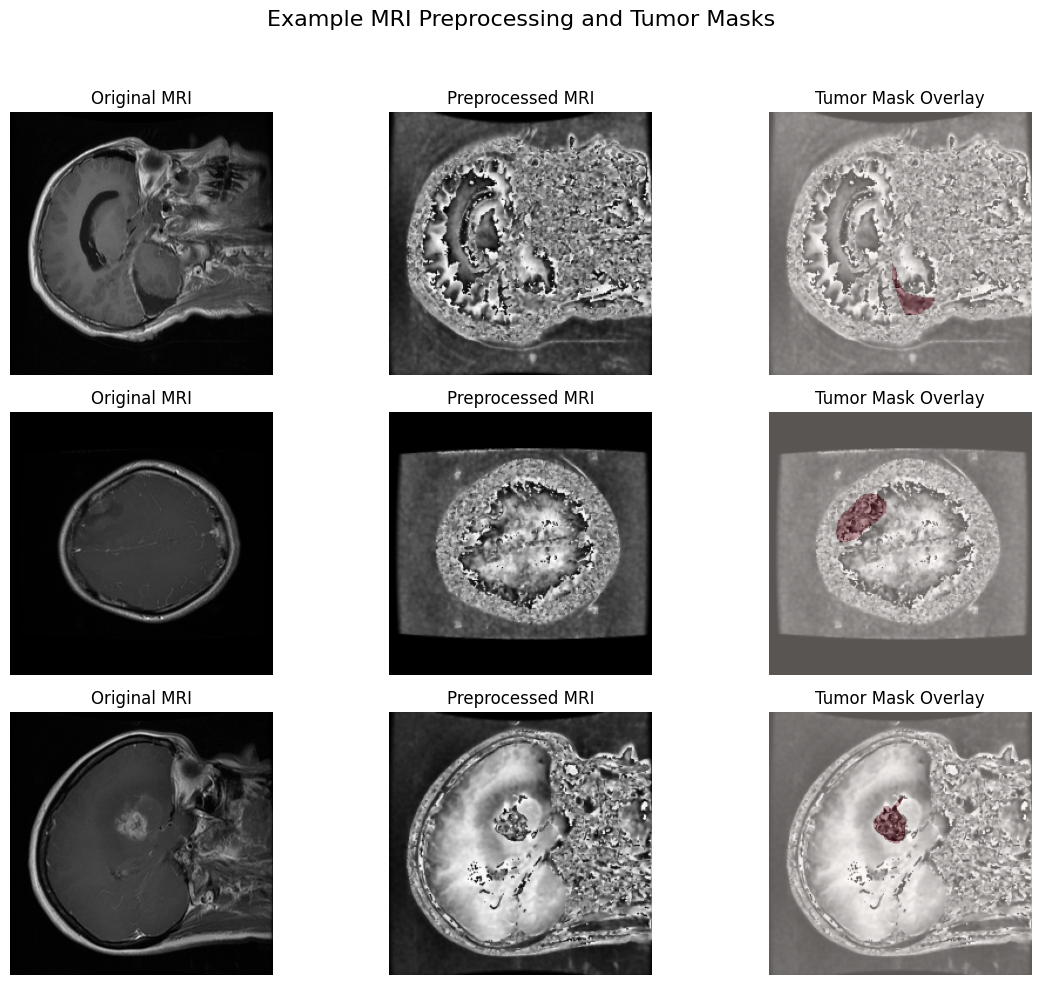

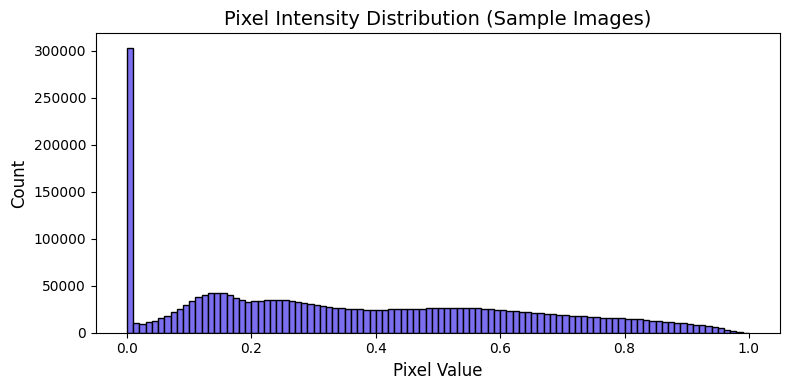

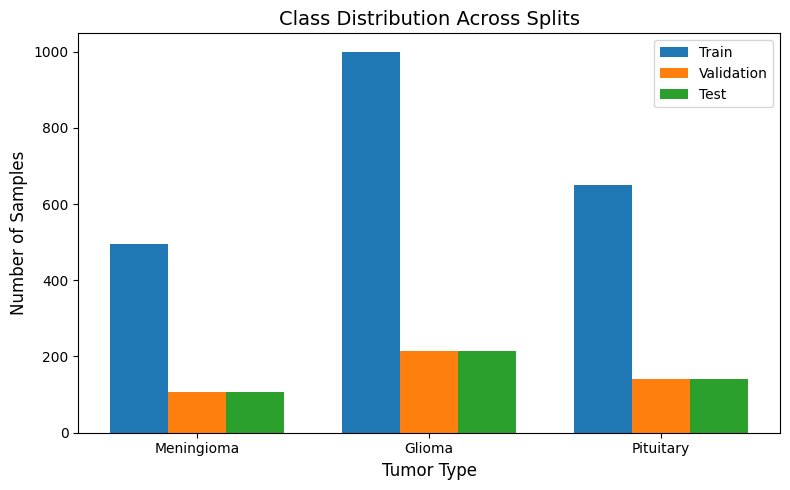

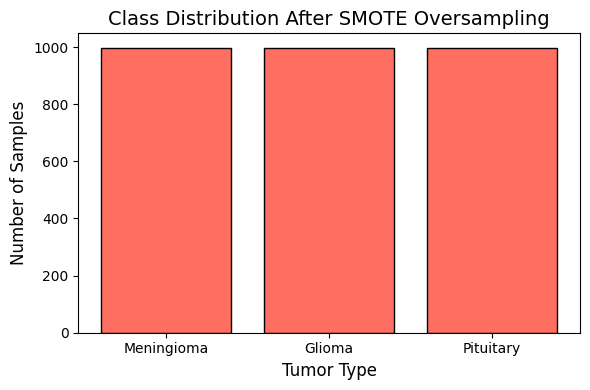


Dataset Overview Table:
        Split  Total Samples  Meningioma  Glioma  Pituitary
0       Train           2144         496     998        650
1  Validation            460         106     214        140
2        Test            460         106     214        140


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from collections import Counter

# ===============================
# Select example images for visualization
# ===============================
example_indices = [0, 1, 2]  # pick first 3 samples
fig, axes = plt.subplots(len(example_indices), 3, figsize=(12, 10))

for i, idx in enumerate(example_indices):
    fname = meta[idx]['filename']

    # Load original MRI
    with h5py.File(os.path.join(input_dir, fname + '.mat'), 'r') as mat:
        orig_img = np.array(mat['cjdata']['image'])

    # Load preprocessed MRI
    pre_img = np.load(os.path.join(preprocessed_img_dir, fname + '.npy'))

    # Load mask
    mask = np.load(os.path.join(preprocessed_mask_dir, fname + '.npy'))

    # Original
    axes[i, 0].imshow(orig_img, cmap='gray')
    axes[i, 0].set_title('Original MRI', fontsize=12)
    axes[i, 0].axis('off')

    # Preprocessed
    axes[i, 1].imshow(pre_img, cmap='gray')
    axes[i, 1].set_title('Preprocessed MRI', fontsize=12)
    axes[i, 1].axis('off')

    # Mask
    axes[i, 2].imshow(pre_img, cmap='gray')
    axes[i, 2].imshow(mask, cmap='Reds', alpha=0.35)
    axes[i, 2].set_title('Tumor Mask Overlay', fontsize=12)
    axes[i, 2].axis('off')

plt.suptitle('Example MRI Preprocessing and Tumor Masks', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ===============================
# Pixel intensity distribution
# ===============================
sample_pixels = []
for idx in range(50):  # sample 50 images for speed
    fname = meta[idx]['filename']
    img = np.load(os.path.join(preprocessed_img_dir, fname + '.npy'))
    sample_pixels.extend(img.flatten())

plt.figure(figsize=(8,4))
plt.hist(sample_pixels, bins=100, color='#7B6FF0', edgecolor='black')
plt.title('Pixel Intensity Distribution (Sample Images)', fontsize=14)
plt.xlabel('Pixel Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# ===============================
# Class distribution in Train/Val/Test splits
# ===============================
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
bar_width = 0.25
tumor_classes = list(label_map.values())
x = np.arange(len(tumor_classes))

plt.figure(figsize=(8,5))
for i, (name, df) in enumerate(splits.items()):
    counts = [df['tumor_type'].value_counts().get(c, 0) for c in tumor_classes]
    plt.bar(x + i*bar_width, counts, width=bar_width, label=name)

plt.xticks(x + bar_width, [c.capitalize() for c in tumor_classes])
plt.xlabel('Tumor Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution Across Splits', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,4))
smote_counts = Counter(y_resampled)
plt.bar([label_map[k+1].capitalize() for k in sorted(smote_counts)], [smote_counts[k] for k in sorted(smote_counts)], color='#FF6F61', edgecolor='black')
plt.xlabel('Tumor Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution After SMOTE Oversampling', fontsize=14)
plt.tight_layout()
plt.show()

# ===============================
# Summary table for publication
# ===============================
summary_table = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Total Samples': [len(train_df), len(val_df), len(test_df)],
})

summary_table['Meningioma'] = [train_df['tumor_type'].value_counts().get('meningioma',0),
                               val_df['tumor_type'].value_counts().get('meningioma',0),
                               test_df['tumor_type'].value_counts().get('meningioma',0)]
summary_table['Glioma'] = [train_df['tumor_type'].value_counts().get('glioma',0),
                           val_df['tumor_type'].value_counts().get('glioma',0),
                           test_df['tumor_type'].value_counts().get('glioma',0)]
summary_table['Pituitary'] = [train_df['tumor_type'].value_counts().get('pituitary',0),
                              val_df['tumor_type'].value_counts().get('pituitary',0),
                              test_df['tumor_type'].value_counts().get('pituitary',0)]

print("\nDataset Overview Table:")
print(summary_table)


In [ ]:
from tensorflow.keras import models, layers
import numpy as np

# ===============================
# CNN Model for Brain Tumor Classification
# ===============================
model = models.Sequential([
    # Input layer: grayscale MRI images 224x224
    layers.Input(shape=(224, 224, 1)),

    # Conv block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Conv block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Conv block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output layer: number of tumor classes
    layers.Dense(len(np.unique(y_resampled)), activation='softmax')
])

# ===============================
# Compile model
# ===============================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # integer labels
    metrics=['accuracy']
)

# ===============================
# Model summary
# ===============================
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,243 (49.36 MB)

 Trainable params: 12,938,243 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import plot_model

# ===============================
# Plot CNN architecture
# ===============================
plot_model(
    model,
    to_file='cnn_architecture.png',  # Save figure
    show_shapes=True,                # Show output shape at each layer
    show_layer_names=True,           # Show layer names
    expand_nested=False,
    dpi=150
)

print("CNN architecture diagram saved as 'cnn_architecture.png'.")


CNN architecture diagram saved as 'cnn_architecture.png'.


In [ ]:
def load_npy_images(df, npy_dir):
    X, y = [], []
    for fname, label in zip(df['filename'], df['label']):
        img = np.load(os.path.join(npy_dir, f"{fname}.npy"))  # already 224x224 and normalized
        X.append(img)
        y.append(label-1)
    X = np.array(X)[..., None]
    y = np.array(y)
    return X, y

# Load validation and test sets much faster
X_val, y_val = load_npy_images(val_df, './preprocessed_images')
X_test, y_test = load_npy_images(test_df, './preprocessed_images')

print(f"Validation shape: {X_val.shape}, Test shape: {X_test.shape}")


Validation shape: (460, 224, 224, 1), Test shape: (460, 224, 224, 1)


In [ ]:
import numpy as np
import os
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# ===============================
# Function to load preprocessed .npy images
# ===============================
def load_npy_dataset(df, npy_dir):
    X, y = [], []
    for fname, label in zip(df['filename'], df['label']):
        img = np.load(os.path.join(npy_dir, f"{fname}.npy"))
        X.append(img)
        y.append(label-1)  # 0-based labels
    X = np.stack(X, axis=0)[..., None]  # (N,224,224,1)
    y = np.array(y, dtype=np.int32)
    return X, y

# Load training, validation, and test sets
X_train, y_train = load_npy_dataset(train_df, './preprocessed_images')
X_val, y_val     = load_npy_dataset(val_df, './preprocessed_images')
X_test, y_test   = load_npy_dataset(test_df, './preprocessed_images')

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")


n_train = X_train.shape[0]
X_train_flat = X_train.reshape(n_train, -1)  # Flatten for SMOTE

smote = SMOTE(random_state=42)
X_res_flat, y_resampled = smote.fit_resample(X_train_flat, y_train)

# Reshape back to (N,224,224,1)
X_resampled = X_res_flat.reshape(-1, 224, 224, 1)
print(f"SMOTE-resampled shape: {X_resampled.shape}, {y_resampled.shape}")

# ===============================
# Create tf.data.Dataset for fast training
# ===============================
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_resampled, y_resampled))
train_dataset = train_dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ===============================
# Callbacks
# ===============================
callbacks = [
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ===============================
# Train the CNN
# ===============================
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=2
)


Train: (2144, 224, 224, 1), (2144,)
Val:   (460, 224, 224, 1), (460,)
Test:  (460, 224, 224, 1), (460,)
SMOTE-resampled shape: (2994, 224, 224, 1), (2994,)
Epoch 1/6

Epoch 1: val_loss improved from inf to 0.44338, saving model to best_model.h5


94/94 - 365s - 4s/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.8978 - val_loss: 0.4434 - learning_rate: 5.0000e-04
Epoch 2/6

Epoch 2: val_loss did not improve from 0.44338
94/94 - 362s - 4s/step - accuracy: 1.0000 - loss: 6.0194e-04 - val_accuracy: 0.8913 - val_loss: 0.4826 - learning_rate: 5.0000e-04
Epoch 3/6

Epoch 3: val_loss did not improve from 0.44338
94/94 - 391s - 4s/step - accuracy: 1.0000 - loss: 2.9473e-04 - val_accuracy: 0.8891 - val_loss: 0.4988 - learning_rate: 5.0000e-04
Epoch 4/6

Epoch 4: val_loss did not improve from 0.44338

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
94/94 - 351s - 4s/step - accuracy: 1.0000 - loss: 2.0839e-04 - val_accuracy: 0.8891 - val_loss: 0.5160 - learning_rate: 5.0000e-04
Epoch 5/6

Epoch 5: val_loss did not improve from 0.44338
94/94 - 378s - 4s/step - accuracy: 1.0000 - loss: 1.7251e-04 - val_accuracy: 0.8891 - val_loss: 0.5224 - learning_rate: 2.5000e-04
Epoch 6/6

Epoch 6: val_loss did not imp

15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
Classification Report:
              precision    recall  f1-score   support

  meningioma       0.78      0.77      0.78       106
      glioma       0.91      0.89      0.90       214
   pituitary       0.93      0.97      0.95       140

    accuracy                           0.89       460
   macro avg       0.88      0.88      0.88       460
weighted avg       0.89      0.89      0.89       460



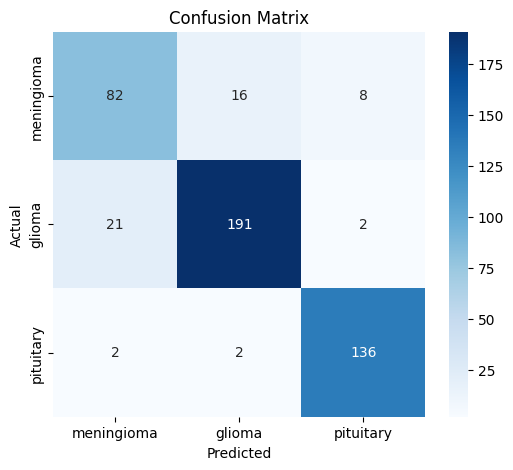

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Class names (must match your labels)
# ===============================
class_names = ["meningioma", "glioma", "pituitary"]  # as in label_map

# ===============================
# Predict on validation set
# ===============================
# Make sure X_val has shape (N,224,224,1)
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# ===============================
# Classification report
# ===============================
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# ===============================
# Confusion matrix
# ===============================
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


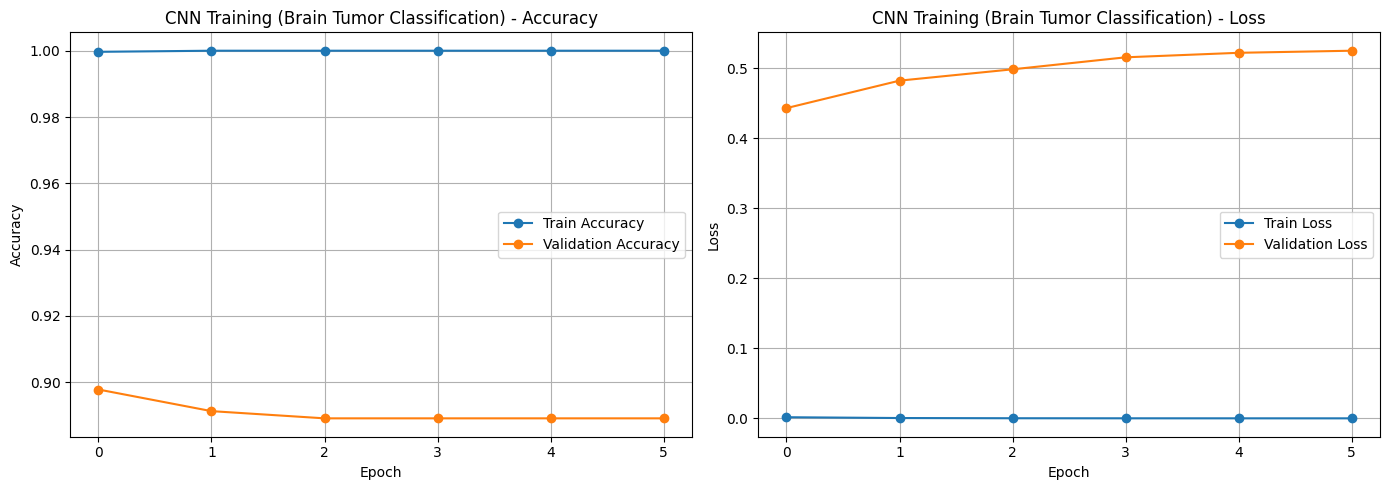

In [ ]:
import matplotlib.pyplot as plt

# ===============================
# Function to plot training & validation curves
# ===============================
def plot_history(hist, title="Training / Validation Curve"):
    """
    Plots accuracy and loss curves for training and validation.

    Args:
        hist: Keras History object returned by model.fit()
        title: Optional string to title the plots
    """
    plt.figure(figsize=(14,5))

    # ----- Accuracy Curve -----
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.grid(True)
    plt.legend()

    # ----- Loss Curve -----
    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Train Loss', marker='o')
    plt.plot(hist.history['val_loss'], label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# ===============================
# Plot training curves for current CNN
# ===============================
plot_history(history, title="CNN Training (Brain Tumor Classification)")

# Optional: If you also fine-tuned another model, e.g., DenseNet121:
if 'history_ft' in locals():
    plot_history(history_ft, title="DenseNet121 Fine-Tuning")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step


/tmp/ipython-input-2677183999.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


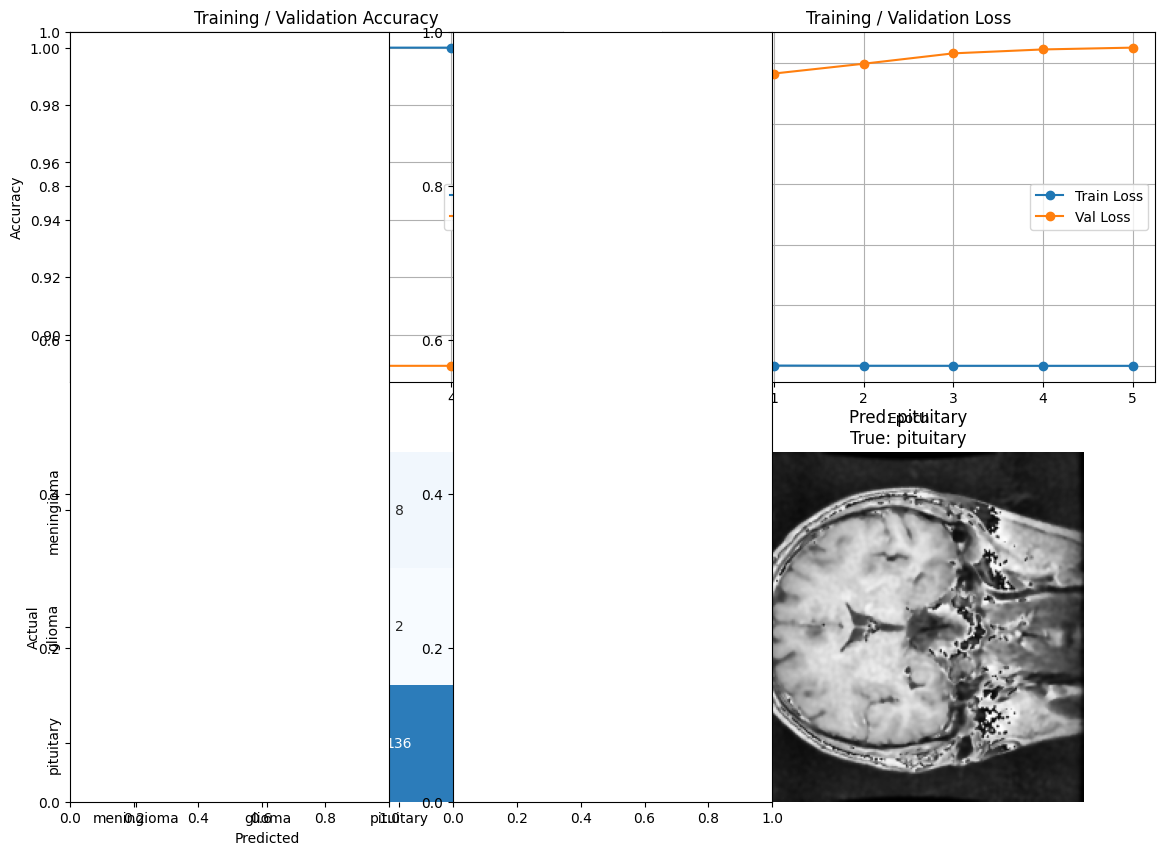

Classification Report (Validation Set):
              precision    recall  f1-score   support

  meningioma       0.78      0.77      0.78       106
      glioma       0.91      0.89      0.90       214
   pituitary       0.93      0.97      0.95       140

    accuracy                           0.89       460
   macro avg       0.88      0.88      0.88       460
weighted avg       0.89      0.89      0.89       460



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------
# Select 3 random validation samples for example predictions
# ------------------------------
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), 3, replace=False)

# Predict on these samples
y_sample_probs = model.predict(X_val[sample_indices])
y_sample_pred  = np.argmax(y_sample_probs, axis=1)

# ------------------------------
# Confusion matrix
# ------------------------------
from sklearn.metrics import confusion_matrix, classification_report
class_names = ["meningioma", "glioma", "pituitary"]
y_val_pred = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, y_val_pred)

# ------------------------------
# Plot combined figure
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1️⃣ Accuracy curve
axes[0,0].plot(history.history['accuracy'], label='Train Acc', marker='o')
axes[0,0].plot(history.history['val_accuracy'], label='Val Acc', marker='o')
axes[0,0].set_title('Training / Validation Accuracy')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True)

# 2️⃣ Loss curve
axes[0,1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0,1].plot(history.history['val_loss'], label='Val Loss', marker='o')
axes[0,1].set_title('Training / Validation Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True)

# 3️⃣ Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1,0])
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_title('Confusion Matrix')

# 4️⃣ Example predictions
for i, idx in enumerate(sample_indices):
    axes[1,1].imshow(X_val[idx,:,:,0], cmap='gray')
    axes[1,1].set_title(f"Pred: {class_names[y_sample_pred[i]]}\nTrue: {class_names[y_val[idx]]}")
    axes[1,1].axis('off')
    if i < len(sample_indices)-1:
        axes[1,1].figure.add_subplot(1, len(sample_indices), i+1)
plt.tight_layout()
plt.show()

# ------------------------------
# Print classification report
# ------------------------------
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, target_names=class_names))


15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step


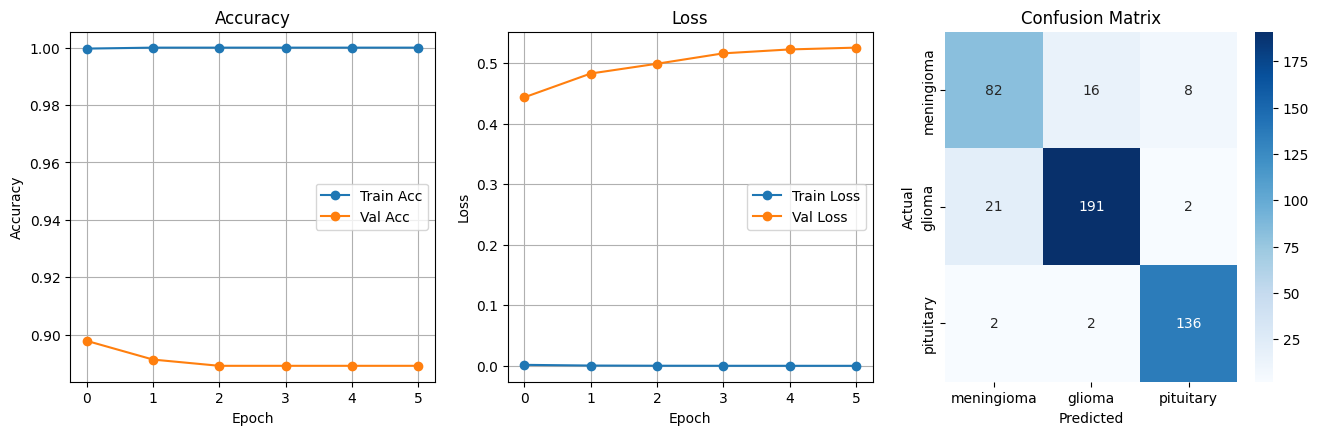

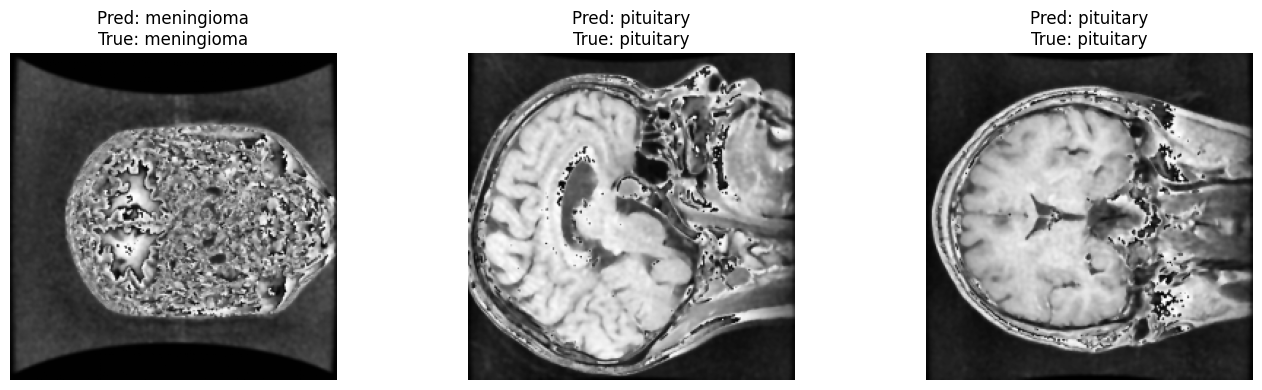

Classification Report (Validation Set):
              precision    recall  f1-score   support

  meningioma       0.78      0.77      0.78       106
      glioma       0.91      0.89      0.90       214
   pituitary       0.93      0.97      0.95       140

    accuracy                           0.89       460
   macro avg       0.88      0.88      0.88       460
weighted avg       0.89      0.89      0.89       460



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------
# Class names
# ------------------------------
class_names = ["meningioma", "glioma", "pituitary"]

# ------------------------------
# Predict on validation set
# ------------------------------
y_val_pred = np.argmax(model.predict(X_val), axis=1)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# ------------------------------
# Select 3 random validation samples for example predictions
# ------------------------------
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), 3, replace=False)
y_sample_pred  = y_val_pred[sample_indices]
y_sample_true  = y_val[sample_indices]

# ------------------------------
# Create combined figure
# ------------------------------
fig = plt.figure(figsize=(16,10))

# ----- Top row: Accuracy & Loss -----
ax1 = plt.subplot2grid((2,3), (0,0), colspan=1)
ax2 = plt.subplot2grid((2,3), (0,1), colspan=1)
ax3 = plt.subplot2grid((2,3), (0,2), colspan=1)

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Acc', marker='o')
ax1.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(True)
ax1.legend()

# Loss
ax2.plot(history.history['loss'], label='Train Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Val Loss', marker='o')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)
ax2.legend()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax3)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_title('Confusion Matrix')

# ----- Bottom row: Example predictions -----
fig2, axes = plt.subplots(1, 3, figsize=(14,4))
for i, idx in enumerate(sample_indices):
    axes[i].imshow(X_val[idx,:,:,0], cmap='gray')
    axes[i].set_title(f"Pred: {class_names[y_sample_pred[i]]}\nTrue: {class_names[y_sample_true[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# ------------------------------
# Print classification report
# ------------------------------
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, target_names=class_names))


15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step


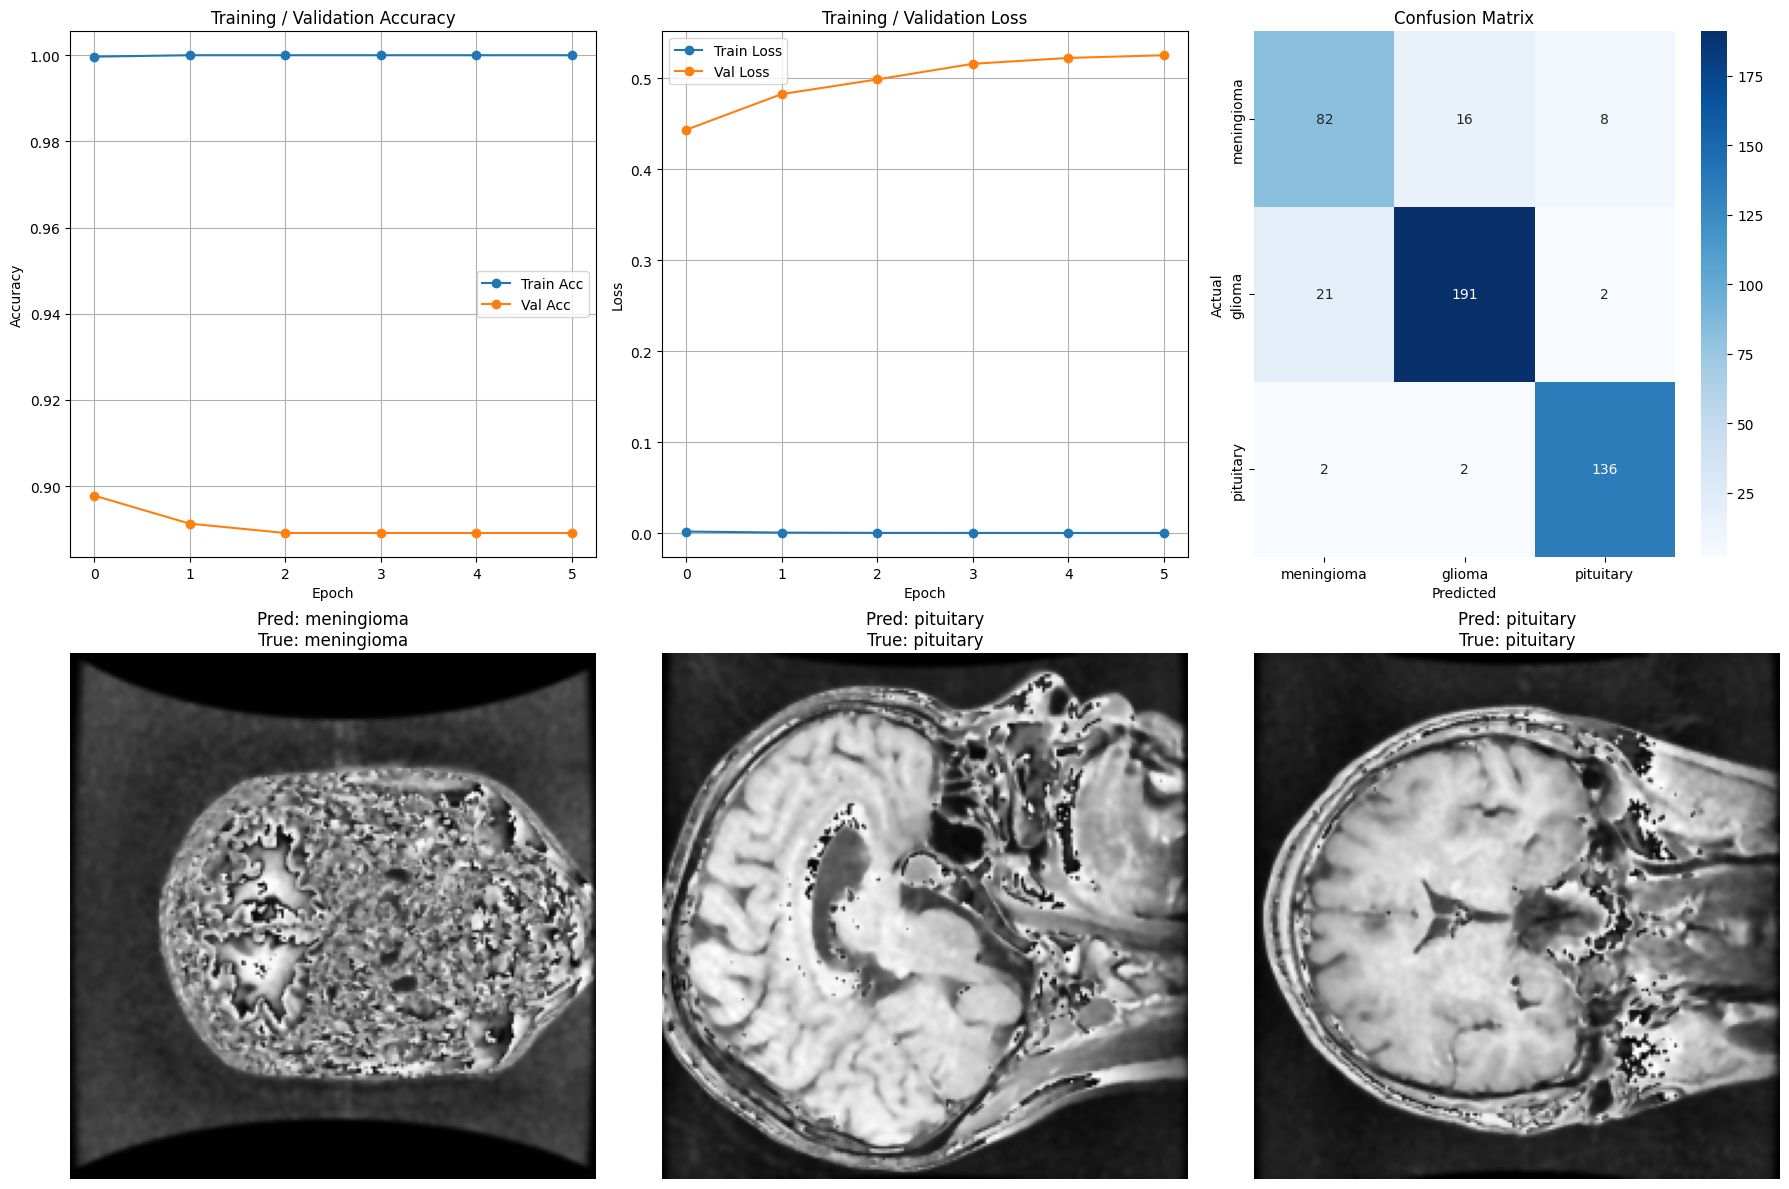

Classification Report (Validation Set):
              precision    recall  f1-score   support

  meningioma       0.78      0.77      0.78       106
      glioma       0.91      0.89      0.90       214
   pituitary       0.93      0.97      0.95       140

    accuracy                           0.89       460
   macro avg       0.88      0.88      0.88       460
weighted avg       0.89      0.89      0.89       460



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------
# Class names
# ------------------------------
class_names = ["meningioma", "glioma", "pituitary"]

# ------------------------------
# Predictions
# ------------------------------
y_val_pred = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, y_val_pred)

# Random validation samples for example predictions
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), 3, replace=False)
y_sample_pred  = y_val_pred[sample_indices]
y_sample_true  = y_val[sample_indices]

# ------------------------------
# Combined figure
# ------------------------------
fig = plt.figure(figsize=(18,12))

# ----- Top row -----
# Accuracy
ax1 = plt.subplot2grid((2,3), (0,0))
ax1.plot(history.history['accuracy'], label='Train Acc', marker='o')
ax1.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
ax1.set_title('Training / Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(True)
ax1.legend()

# Loss
ax2 = plt.subplot2grid((2,3), (0,1))
ax2.plot(history.history['loss'], label='Train Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Val Loss', marker='o')
ax2.set_title('Training / Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)
ax2.legend()

# Confusion Matrix
ax3 = plt.subplot2grid((2,3), (0,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax3)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_title('Confusion Matrix')

# ----- Bottom row: Example predictions -----
for i, idx in enumerate(sample_indices):
    ax = plt.subplot2grid((2,3), (1,i))
    ax.imshow(X_val[idx,:,:,0], cmap='gray')
    ax.set_title(f"Pred: {class_names[y_sample_pred[i]]}\nTrue: {class_names[y_sample_true[i]]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# ------------------------------
# Classification report
# ------------------------------
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, target_names=class_names))


15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step


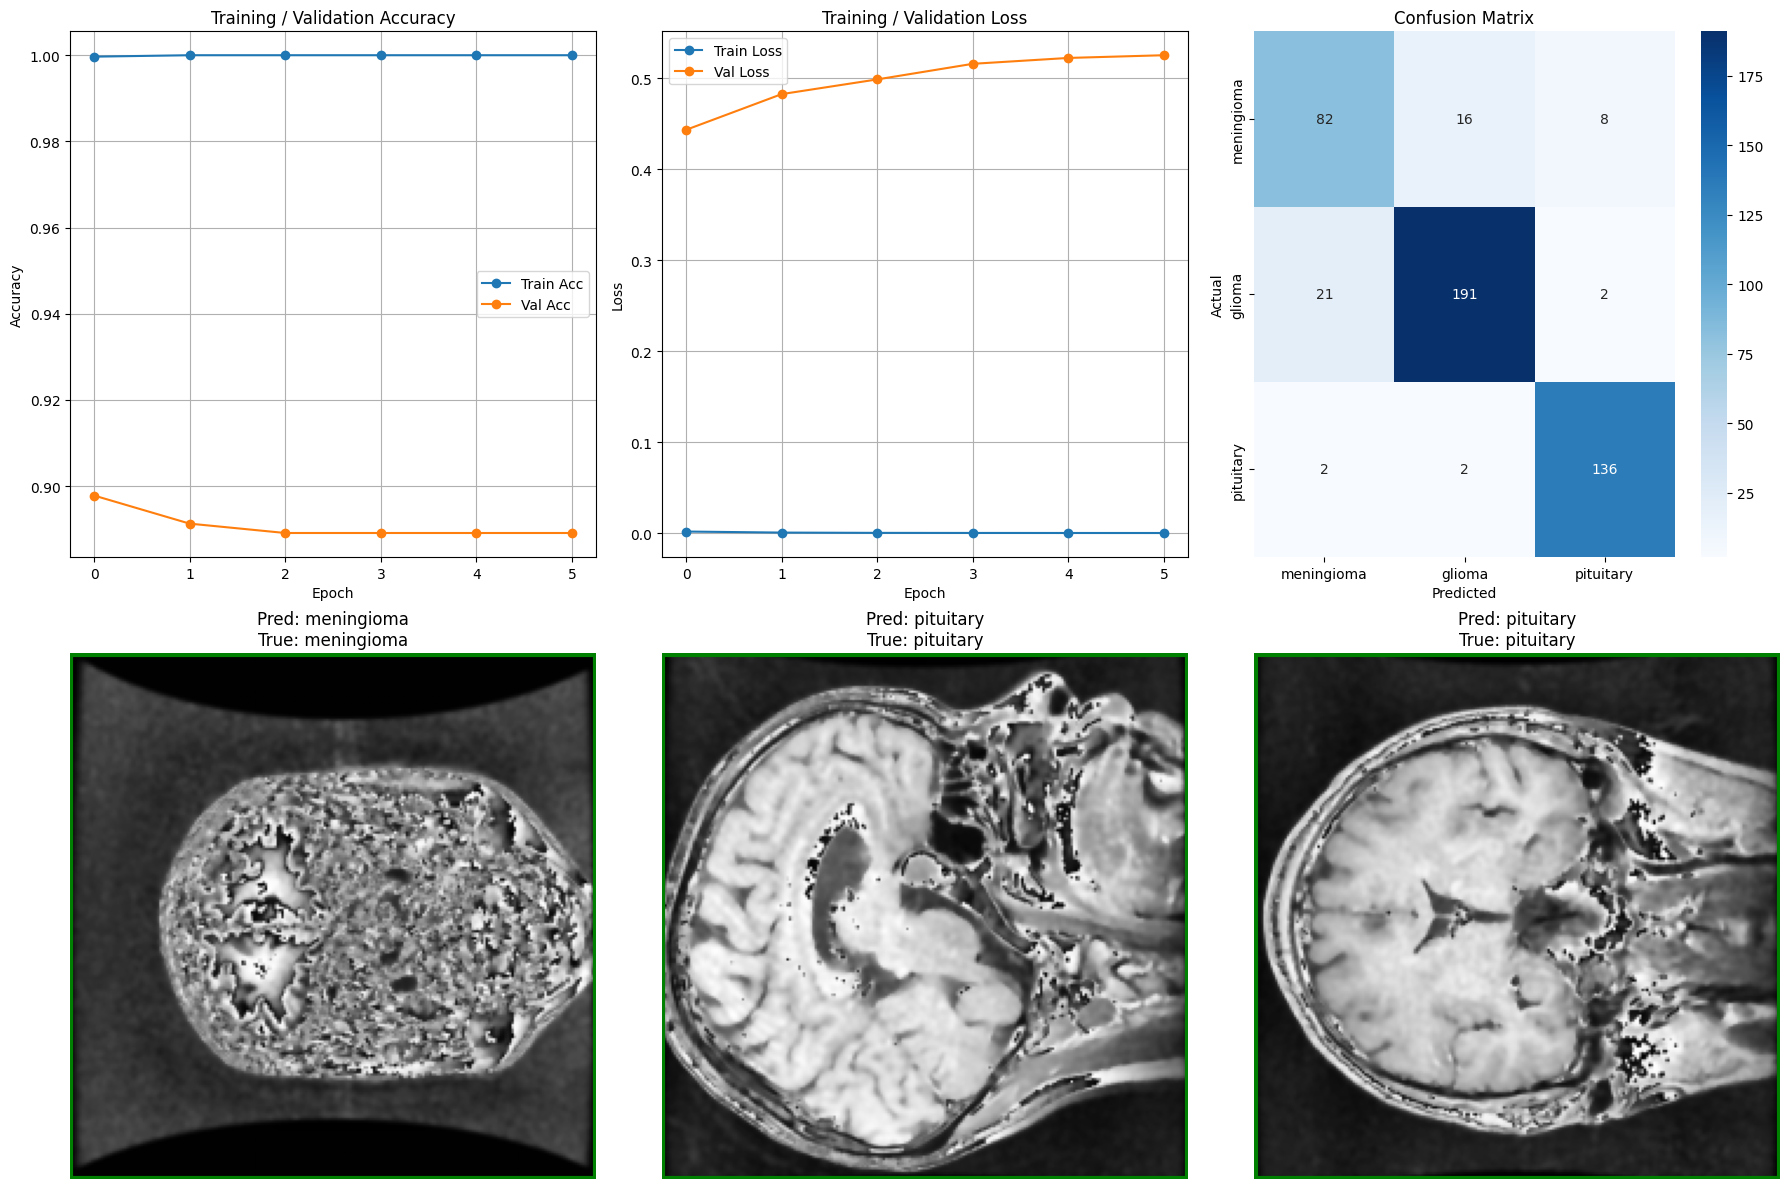

Classification Report (Validation Set):
              precision    recall  f1-score   support

  meningioma       0.78      0.77      0.78       106
      glioma       0.91      0.89      0.90       214
   pituitary       0.93      0.97      0.95       140

    accuracy                           0.89       460
   macro avg       0.88      0.88      0.88       460
weighted avg       0.89      0.89      0.89       460



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib.patches import Rectangle

# ------------------------------
# Class names
# ------------------------------
class_names = ["meningioma", "glioma", "pituitary"]

# ------------------------------
# Predictions
# ------------------------------
y_val_pred = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, y_val_pred)

# Random validation samples for example predictions
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), 3, replace=False)
y_sample_pred  = y_val_pred[sample_indices]
y_sample_true  = y_val[sample_indices]

# ------------------------------
# Combined figure
# ------------------------------
fig = plt.figure(figsize=(18,12))

# ----- Top row -----
# Accuracy
ax1 = plt.subplot2grid((2,3), (0,0))
ax1.plot(history.history['accuracy'], label='Train Acc', marker='o')
ax1.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
ax1.set_title('Training / Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(True)
ax1.legend()

# Loss
ax2 = plt.subplot2grid((2,3), (0,1))
ax2.plot(history.history['loss'], label='Train Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Val Loss', marker='o')
ax2.set_title('Training / Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)
ax2.legend()

# Confusion Matrix
ax3 = plt.subplot2grid((2,3), (0,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax3)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_title('Confusion Matrix')

# ----- Bottom row: Example predictions with color-coded borders -----
for i, idx in enumerate(sample_indices):
    ax = plt.subplot2grid((2,3), (1,i))
    ax.imshow(X_val[idx,:,:,0], cmap='gray')
    ax.set_title(f"Pred: {class_names[y_sample_pred[i]]}\nTrue: {class_names[y_sample_true[i]]}")
    ax.axis('off')

    # Add colored border
    if y_sample_pred[i] == y_sample_true[i]:
        color = 'green'  # correct
    else:
        color = 'red'    # incorrect
    rect = Rectangle((0,0), X_val.shape[2]-1, X_val.shape[1]-1,
                     linewidth=3, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

plt.tight_layout()
plt.show()

# ------------------------------
# Classification report
# ------------------------------
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, target_names=class_names))


15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step
Test Set Classification Report:
              precision    recall  f1-score   support

  meningioma       0.86      0.92      0.89       106
      glioma       0.95      0.92      0.93       214
   pituitary       0.97      0.98      0.98       140

    accuracy                           0.93       460
   macro avg       0.93      0.94      0.93       460
weighted avg       0.94      0.93      0.94       460



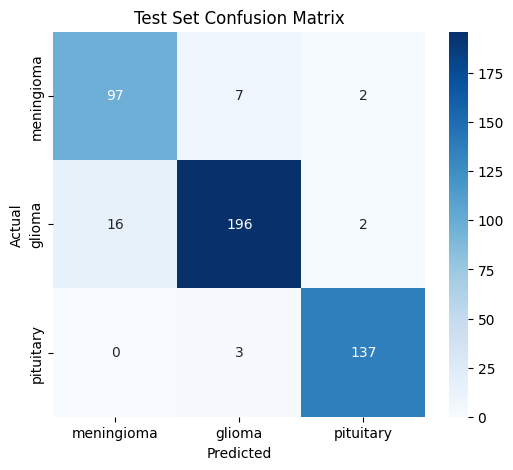

In [ ]:
# Predict on test set
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Test Set Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Set Confusion Matrix')
plt.show()


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze for initial training

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_dataset_aug = datagen.flow(X_resampled, y_resampled, batch_size=32)


In [ ]:
# Class names for tumor types
class_names = ["meningioma", "glioma", "pituitary"]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# Load preprocessed data (already done)
# ------------------------------
# X_train, y_train, X_val, y_val, X_test, y_test
# class_names = ["meningioma", "glioma", "pituitary"]

# ------------------------------
# DenseNet121 Transfer Learning
# ------------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base layers initially

model_tl = models.Sequential([
    layers.Input(shape=(224,224,3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_tl.summary()

# ------------------------------
# Convert grayscale to 3-channel for DenseNet
# ------------------------------
def to_rgb(x):
    return np.repeat(x, 3, axis=-1)

X_train_rgb = to_rgb(X_train)
X_val_rgb   = to_rgb(X_val)
X_test_rgb  = to_rgb(X_test)

# ------------------------------
# Callbacks
# ------------------------------
callbacks = [
    ModelCheckpoint('best_densenet_model.h5', save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ------------------------------
# Train Transfer Learning Model (frozen base)
# ------------------------------
history_tl = model_tl.fit(
    X_train_rgb, y_train,
    epochs=10,          # fewer epochs to save time
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks,
    verbose=2
)

# ------------------------------
# Fine-tuning: unfreeze last DenseNet block
# ------------------------------
base_model.trainable = True
for layer in base_model.layers[:-50]:  # freeze first layers, unfreeze last 50
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    X_train_rgb, y_train,
    epochs=6,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks,
    verbose=2
)

# ------------------------------
# Evaluation: Validation & Test
# ------------------------------
def evaluate_model(model, X, y, class_names, title=""):
    y_pred = np.argmax(model.predict(X), axis=1)
    print(f"Classification Report ({title}):")
    print(classification_report(y, y_pred, target_names=class_names))

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix ({title})')
    plt.show()

evaluate_model(model_tl, X_val_rgb, y_val, class_names, title="Validation")
evaluate_model(model_tl, X_test_rgb, y_test, class_names, title="Test")

# ------------------------------
# Training / Validation Curves
# ------------------------------
def plot_history(hist, title="Training/Validation Curve"):
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_history(history_tl, title="DenseNet121 Transfer Learning")
plot_history(history_ft, title="DenseNet121 Fine-Tuning")

# ------------------------------
# Grad-CAM Visualization for 3 examples
# ------------------------------
def grad_cam(model, img, class_idx):
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None:
        raise ValueError("No Conv2D layer found for Grad-CAM.")

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    img_tensor = img[None, ...]
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)[0]
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

# Display Grad-CAM for 3 random test images
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_rgb), 3, replace=False)

plt.figure(figsize=(15,5))
for i, idx in enumerate(sample_idx):
    img = X_test_rgb[idx]
    pred_class = np.argmax(model_tl.predict(img[None,...]))
    true_class = y_test[idx]
    heatmap = grad_cam(model_tl, img, pred_class)

    plt.subplot(1,3,i+1)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title(f"Pred: {class_names[pred_class]}\nTrue: {class_names[true_class]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,091 (27.35 MB)

 Trainable params: 131,587 (514.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

...

67/67 - 478s - 7s/step - accuracy: 0.6768 - loss: 0.7299 - val_accuracy: 0.7522 - val_loss: 0.5381 - learning_rate: 1.0000e-03
Epoch 2/10

Epoch 2: val_loss improved from 0.53814 to 0.52751, saving model to best_densenet_model.h5


67/67 - 454s - 7s/step - accuracy: 0.8158 - loss: 0.4571 - val_accuracy: 0.8174 - val_loss: 0.5275 - learning_rate: 1.0000e-03
Epoch 3/10

Epoch 3: val_loss improved from 0.52751 to 0.37222, saving model to best_densenet_model.h5


67/67 - 488s - 7s/step - accuracy: 0.8424 - loss: 0.3820 - val_accuracy: 0.8500 - val_loss: 0.3722 - learning_rate: 1.0000e-03
Epoch 4/10

Epoch 4: val_loss improved from 0.37222 to 0.34413, saving model to best_densenet_model.h5


67/67 - 441s - 7s/step - accuracy: 0.8605 - loss: 0.3580 - val_accuracy: 0.8435 - val_loss: 0.3441 - learning_rate: 1.0000e-03
Epoch 5/10

Epoch 5: val_loss improved from 0.34413 to 0.33843, saving model to best_densenet_model.h5


67/67 - 443s - 7s/step - accuracy: 0.8755 - loss: 0.3084 - val_accuracy: 0.8761 - val_loss: 0.3384 - learning_rate: 1.0000e-03
Epoch 6/10
